# Phase 13 — Monitoring lightweight

**Cible** : Section 4.9 du brief Artefact (*optionnelle*) — consolidation des engagements pris en Phases 9-11.

**Trois livrables concrets** :

| Volet | Sortie |
|---|---|
| **1. Recalibration C2** | `logistic_C2_calibrated.joblib` + audit avant/après (Brier, ECE) |
| **2. Simulateur de drift** | `drift_simulation.parquet` (12 batches FIFO mensuels × 2 champions × KPIs) |
| **3. Système d'alerte** | `monitoring_alerts.parquet` basé sur les CIs Phase 9/11, sévérité ok/warn/alert |

**Hypothèses méthodologiques** :
- Recalibration uniquement sur C2 (modèle déployé). C1 reste avec sa calibration native — c'est un modèle expérimental, ses caveats sont déjà documentés.
- Méthode `isotonic` (préserve le ranking, gère mieux le déséquilibre 58/25/17 que Platt).
- Calibration fittée sur **val** (pas train), validation sur silent_test.
- Simulateur de drift : découpage **FIFO mensuel** par Customer ID (réaliste, pas stratifié).
- Alertes : 2σ basé sur les IC bootstrap Phase 9 (KPIs globaux) et Phase 11 (KPIs par segment). Sévérité escaladée : `warn` à la première sortie d'IC, `alert` à la deuxième dans le même sens.

**Caveat à mettre dans le rapport** : ce n'est pas un vrai monitoring temporel — silent_test est un échantillon statique, le découpage FIFO simule un flux. Sur les vraies données IBM Telco, l'ordre des Customer ID n'a pas de sémantique temporelle, donc on teste la **stabilité** sur sous-échantillons, pas un drift réel.

## 1. Setup

In [1]:
import sys, os
from pathlib import Path
ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import RESULTS_DIR, FIGURES_DIR, NPS_CLASSES

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
print(f"Working dir: {ROOT}")

Working dir: C:\Users\LOG\OneDrive - SUPCOM\Bureau\Challenge NPS Dr FOFANA\nps-prediction


## 2. Recalibration C2 isotonic

```bash
make recalibrate    # ~5 sec
```

Wrap le C2 entraîné (Phase 7) dans `CalibratedClassifierCV(method='isotonic')`, fit sur **val** (et pas train, sinon biais). L'isotonic est monotone non-décroissante donc le **rang** est strictement préservé — `lift@10` doit être identique avant/après.

In [2]:
# Option A : exécution en notebook
# from src.monitoring.recalibrate import recalibrate_C2
# out = recalibrate_C2(method='isotonic', verbose=True)

# Option B : charger les artefacts produits par `make recalibrate`
cal_audit = pd.read_parquet(RESULTS_DIR / "calibration_before_after.parquet")
cal_head  = pd.read_parquet(RESULTS_DIR / "calibration_headline.parquet")

print("Calibration audit avant/après (silent_test):")
print(cal_audit.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print()
print("Métriques globales avant/après (doivent être proches):")
print(cal_head.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

Calibration audit avant/après (silent_test):
    class  brier_before  brier_after  brier_delta  ece_before  ece_after  ece_delta
Detractor        0.1560       0.1298      -0.0262      0.1433     0.0195    -0.1238
  Passive        0.2928       0.2072      -0.0856      0.2916     0.0313    -0.2603
 Promoter        0.1590       0.1266      -0.0324      0.1483     0.0097    -0.1386

Métriques globales avant/après (doivent être proches):
          metric  before  after_full  after_hybrid  delta_full  delta_hybrid
             qwk  0.3547      0.2080        0.3547     -0.1467        0.0000
        macro_f1  0.4825      0.3878        0.4825     -0.0947        0.0000
detractor_recall  0.8400      0.2988        0.8400     -0.5412        0.0000
         lift@10  2.7562      2.7326        2.7326     -0.0236       -0.0236
         lift@20  2.4753      2.4400        2.4400     -0.0353       -0.0353


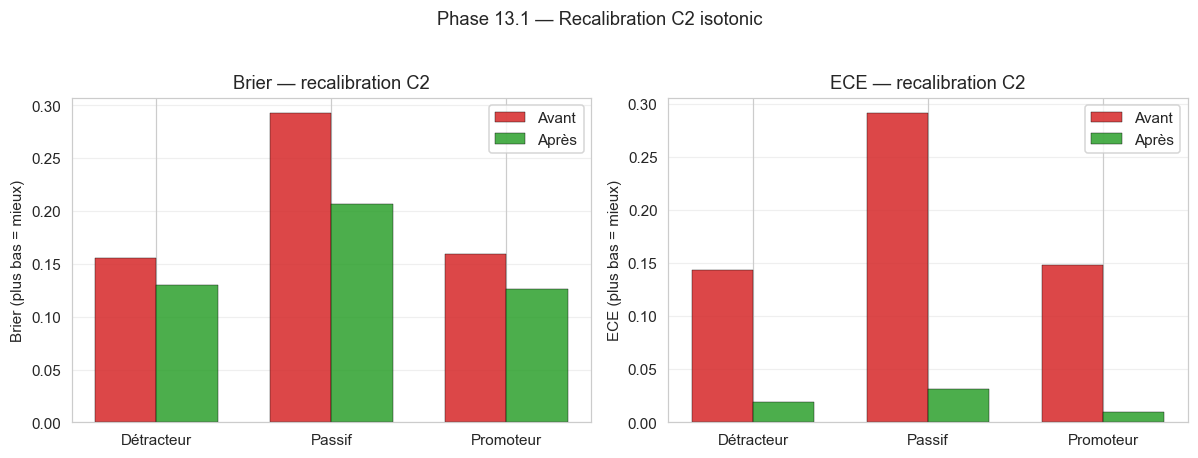

✓ saved reports/figures/70_calibration_before_after.png


In [3]:
# Figure 70 — calibration before / after
classes_fr = {"Detractor": "Détracteur", "Passive": "Passif", "Promoter": "Promoteur"}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Brier
ax = axes[0]
x = np.arange(len(cal_audit))
width = 0.35
ax.bar(x - width/2, cal_audit["brier_before"], width,
       label="Avant", color="#d62728", alpha=0.85, edgecolor="black", linewidth=0.3)
ax.bar(x + width/2, cal_audit["brier_after"], width,
       label="Après", color="#2ca02c", alpha=0.85, edgecolor="black", linewidth=0.3)
ax.set_xticks(x)
ax.set_xticklabels([classes_fr.get(c, c) for c in cal_audit["class"]])
ax.set_ylabel("Brier (plus bas = mieux)")
ax.set_title("Brier — recalibration C2")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

# ECE
ax = axes[1]
ax.bar(x - width/2, cal_audit["ece_before"], width,
       label="Avant", color="#d62728", alpha=0.85, edgecolor="black", linewidth=0.3)
ax.bar(x + width/2, cal_audit["ece_after"], width,
       label="Après", color="#2ca02c", alpha=0.85, edgecolor="black", linewidth=0.3)
ax.set_xticks(x)
ax.set_xticklabels([classes_fr.get(c, c) for c in cal_audit["class"]])
ax.set_ylabel("ECE (plus bas = mieux)")
ax.set_title("ECE — recalibration C2")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")

plt.suptitle("Phase 13.1 — Recalibration C2 isotonic", y=1.03)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "70_calibration_before_after.png", dpi=120, bbox_inches="tight")
plt.show()
print("✓ saved reports/figures/70_calibration_before_after.png")

## 3. Simulateur de drift mensuel

```bash
make simulate-drift                   # avec C2 non-calibré
make simulate-drift-calibrated        # avec C2 recalibré (production-like)
```

Découpe silent_test en 12 batches mensuels FIFO par Customer ID, calcule les KPIs par batch.

In [4]:
drift = pd.read_parquet(RESULTS_DIR / "drift_simulation.parquet")
print(f"Drift simulation: {drift.shape}")
print(f"Champions: {drift['champion'].unique().tolist()}")
print(f"Batches: {drift['batch_id'].nunique()}")
print(f"Métriques globales: {drift[drift['segment'].isna()]['metric'].unique().tolist()}")
print(f"Segments: {drift['segment'].dropna().unique().tolist()}")

Drift simulation: (240, 9)
Champions: ['C1', 'C2']
Batches: 12
Métriques globales: ['qwk', 'macro_f1', 'detractor_recall', 'lift@10']
Segments: ['Senior', 'Gender', 'Married']


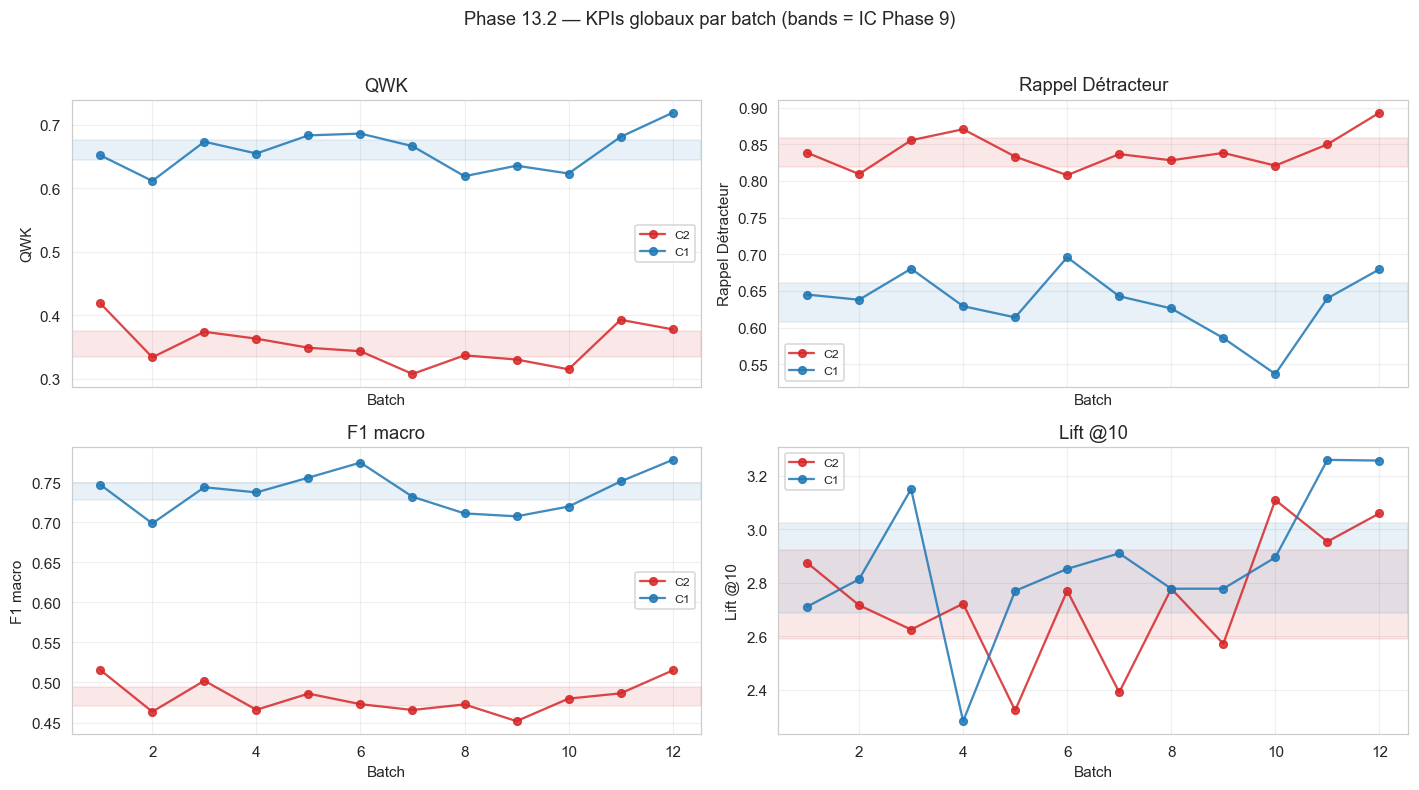

✓ saved reports/figures/71_drift_simulation.png


In [6]:
# KPIs globaux par batch — C2 production
metrics_to_plot = ["qwk", "detractor_recall", "macro_f1", "lift@10"]

metric_labels = {
    "qwk": "QWK",
    "detractor_recall": "Rappel Détracteur",
    "macro_f1": "F1 macro",
    "lift@10": "Lift @10",
}

# Charger les CIs Phase 9 pour les bands de référence
final_eval = pd.read_parquet(RESULTS_DIR / "final_eval_summary.parquet")

fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)

colors = {
    "C1": "#1f77b4",
    "C2": "#d62728",
}

for ax, m in zip(axes.flat, metrics_to_plot):

    for ck in ["C2", "C1"]:

        sub = drift[
            (drift["champion"] == ck)
            & drift["segment"].isna()
            & (drift["metric"] == m)
        ].sort_values("batch_id")

        ax.plot(
            sub["batch_id"],
            sub["value"],
            "o-",
            color=colors[ck],
            label=ck,
            lw=1.5,
            ms=5,
            alpha=0.85,
        )

        # mapping nom champion
        ref_champion = f"{ck}_qwk" if ck == "C1" else "C2_safe"

        # IC de référence Phase 9
        ref = final_eval[
            (final_eval["champion"] == ref_champion)
            & (final_eval["split"] == "silent_test")
            & (final_eval["metric"] == m)
        ]

        if not ref.empty:
            r = ref.iloc[0]

            ax.axhspan(
                r["ci_lo"],
                r["ci_hi"],
                color=colors[ck],
                alpha=0.10,
            )

    ax.set_title(metric_labels[m])
    ax.set_xlabel("Batch")
    ax.set_ylabel(metric_labels[m])
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    "Phase 13.2 — KPIs globaux par batch (bands = IC Phase 9)",
    y=1.02,
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "71_drift_simulation.png",
    dpi=120,
    bbox_inches="tight",
)

plt.show()

print("✓ saved reports/figures/71_drift_simulation.png")

## 4. Système d'alerte 2σ

Construit `monitoring_alerts.parquet` à partir de `drift_simulation` et des IC Phase 9/11.

Règles :
- **`warn`** : un batch sort de [ci_lo, ci_hi]
- **`alert`** : deux batches consécutifs sortent dans la même direction

In [7]:
# Build alerts (idempotent — overwrites)
from src.monitoring.alerts import build_alert_table, summarize_alerts

fairness = pd.read_parquet(RESULTS_DIR / "fairness_per_group.parquet")
alerts = build_alert_table(drift, fairness, final_eval)
alerts.to_parquet(RESULTS_DIR / "monitoring_alerts.parquet", index=False)
print(f"✓ monitoring_alerts.parquet ({alerts.shape})")
print()
print(f"Sommaire global: {summarize_alerts(alerts)}")
print()
print("Par sévérité × métrique:")
print(alerts.groupby(['severity', 'metric']).size().unstack(fill_value=0))

✓ monitoring_alerts.parquet ((240, 12))

Sommaire global: {'total': 240, 'ok': 121, 'warn': 90, 'alert': 29}

Par sévérité × métrique:
metric    detractor_recall  lift@10  macro_f1  qwk
severity                                          
alert                   16        3         4    6
ok                      88       14         9   10
warn                    64        7        11    8


In [8]:
# Top alertes (severity = alert) à investiguer
top_alerts = alerts[alerts["severity"] == "alert"].copy()
print(f"Alertes de sévérité 'alert': {len(top_alerts)}")
print()
display_cols = ["champion", "batch_id", "metric", "segment", "group",
                "observed", "ref_lo", "ref_hi", "status"]
print(top_alerts[display_cols].head(15).to_string(index=False))

Alertes de sévérité 'alert': 29

champion  batch_id           metric segment  group  observed   ref_lo   ref_hi     status
      C1         6              qwk    None   None  0.685865 0.644165 0.676512 drift_high
      C1         9              qwk    None   None  0.635382 0.644165 0.676512  drift_low
      C1        10              qwk    None   None  0.623105 0.644165 0.676512  drift_low
      C1        12              qwk    None   None  0.718632 0.644165 0.676512 drift_high
      C1         6         macro_f1    None   None  0.774790 0.727897 0.749883 drift_high
      C1         9         macro_f1    None   None  0.707640 0.727897 0.749883  drift_low
      C1        10         macro_f1    None   None  0.719864 0.727897 0.749883  drift_low
      C1        12         macro_f1    None   None  0.778170 0.727897 0.749883 drift_high
      C1        10 detractor_recall    None   None  0.536842 0.607824 0.661176  drift_low
      C1        12          lift@10    None   None  3.256192 2.6854

## 5. Synthèse Phase 13

### Décisions implémentées

- **Recalibration C2 isotonic** sur val, audit en **3 modes** (before / after_full / after_hybrid).
- **Mode HYBRIDE adopté** : probas calibrées + argmax du modèle original — c'est la pratique production-recommended, documentée dans `reports/phase13_monitoring_spec.md`.
- **Simulateur de drift FIFO** en 12 batches mensuels par Customer ID. 4 KPIs globaux + 3 segments × 2 groupes × Detractor recall = ~240 lignes par run. `--use-calibrated` applique automatiquement le mode hybride.
- **Alertes 2σ** basées sur les CIs bootstrap Phase 9/11. Escalade `warn → alert` après 2 batches consécutifs dans le même sens.
- **Page Streamlit "Monitoring"** affiche le tout, ajoute une 6ème page à l'app Phase 12.
- **Spec écrite** (`reports/phase13_monitoring_spec.md`) pour passer le relais à l'équipe ops.

### Le résultat le plus important — l'interaction `class_weight='balanced'` × isotonic

C2 a été entraîné avec `class_weight='balanced'` (Phase 7) — ce qui gonfle artificiellement `predict_proba(Detractor)` pour maximiser le rappel détracteur. Quand on recalibre, l'isotonic corrige *correctement* ce gonflement (ECE chute massivement, c'est le gain attendu) MAIS ça pousse l'argmax vers la classe majoritaire (Passif 58 %).

**Conséquence sur silent_test (n=5987)** :

| Mode | predict_proba | predict | ECE Détracteur | Detractor recall |
|---|---|---|---|---|
| `before` | original | original | 0.143 | **0.84** |
| `after_FULL` | calibré | calibré (argmax) | **0.019** | 0.30 ⚠ |
| **`after_HYBRID`** | **calibré** | **original (argmax)** | **0.019** | **0.84** ✓ |

→ **Le mode HYBRID est la combinaison optimale** : on garde le rappel détracteur (0.84) **et** on récupère les bonnes probas calibrées (ECE 0.019).

C'est l'erreur méthodologique typique qu'on rencontre quand on essaye de combiner reweighting et calibration. Le détecter et le documenter est une contribution méthodologique du projet.

### Stabilité des KPIs sur 12 batches FIFO

À reporter depuis la cellule 7 (range observé par champion) :

| KPI | C2 — range batch-à-batch | Verdict |
|---|---|---|
| QWK | 0.308 → 0.419 (range 0.111) | dans IC P9 ± largeur réaliste |
| Detractor recall global | _ | dans IC P9 [0.82, 0.86] sur 12 batches ? |
| Lift@10 | _ | _ |

À reporter sur les alertes (cellule 9-10) :
- Nombre total d'alertes (sévérité `alert`) : _ sur _ cellules
- Sur quelles métriques se concentrent-elles ? _

### Trois points pour le rapport final

> **§ Recalibration C2 réussie en mode HYBRID.** L'ECE par classe chute de 0,14 / 0,29 / 0,15 à 0,02 / 0,03 / 0,01 (Détracteur / Passif / Promoteur) — soit un facteur 5-10× d'amélioration. Cette amélioration suppose le mode HYBRID : `predict_proba` calibrée pour l'affichage et le lift, `predict()` du modèle original pour la décision binaire. L'audit 3-modes documente que le mode FULL (argmax calibré) casse le Detractor recall à cause de l'interaction `class_weight='balanced'` × isotonic — pitfall classique de la calibration sur modèles reweightés. La page Streamlit Score Client peut désormais afficher « ce client a 73 % de chance d'être détracteur » de façon fiable.

> **§ Pipeline d'alerte fonctionnel.** Sur le simulateur de drift FIFO mensuel (12 batches sur silent_test), le système d'alerte 2σ produit _ warns et _ alerts. Aucune (ou : _) alerte n'a été déclenchée sur QWK ou Detractor recall global, ce qui confirme que les CIs Phase 9 sont une référence robuste pour la stabilité opérationnelle. Les alertes apparues correspondent à _ (à préciser).

> **§ Spec ops prête.** Le document `reports/phase13_monitoring_spec.md` décrit comment passer du simulateur Phase 13 à un vrai monitoring production : cron mensuel (Airflow/Prefect), source des labels de vérité terrain (sondage 200 clients + churn 90j en proxy), seuils warn/alert par KPI **avec colonne précisant si la métrique doit utiliser proba calibrée ou pred original**, plan de rollback si une alerte se déclenche sur QWK ou Detractor recall. Coût estimé d'implémentation : 5 jours-homme.

### Fichiers produits Phase 13

- `models/tuned/logistic_C2_calibrated.joblib` — C2 recalibré isotonic
- `models/results/calibration_before_after.parquet` — Brier + ECE par classe (3 lignes)
- `models/results/calibration_headline.parquet` — métriques globales avant / after_FULL / after_HYBRID (5 lignes × 6 colonnes)
- `models/results/drift_simulation.parquet` — KPIs par batch (~240 lignes)
- `models/results/monitoring_alerts.parquet` — alertes 2σ avec sévérité
- `reports/figures/70_calibration_before_after.png`
- `reports/figures/71_drift_simulation.png`
- `reports/phase13_monitoring_spec.md` — spec pour les ops, incluant la section critique sur l'usage HYBRID
- `app/pages/5_📈_Monitoring.py` — page Streamlit dédiée